In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as sst
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.feature_selection import f_classif, chi2, SelectKBest, SelectPercentile
from collections import Counter
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, precision_recall_curve, roc_curve, RocCurveDisplay, roc_auc_score, average_precision_score
from sklearn.decomposition import PCA

In [ ]:
dataset = pd.read_csv('/content/drive/My Drive/SYSC5405/Project/train_data.csv')

# print("Any NaN value in the dataset: ", dataset.isnull().values.any())
# print("Class", Counter(dataset.Label))
# print("Unique columns: ", len(set(dataset.columns)))
# print(dataset.shape)    
# print("Duplicated rows: ", dataset.duplicated().sum())

## are there any categorical variables that need to be one hot encoded??
# dataset.describe()

y = dataset.Label
X = dataset.drop(["Label","KIBA"],axis="columns")
# X = dataset.drop("Label",axis="columns")

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,stratify=y)#random_state=2)#,shuffle=True)#, 


After pruning:

Accuracy:  0.8180962661573805
Precision:  0.7455213596692697
Recall:  0.21240675304279544
Sensitivity:  0.21240675304279544
Specificity:  0.9805532153889357
F1 score:  0.33061723365247503


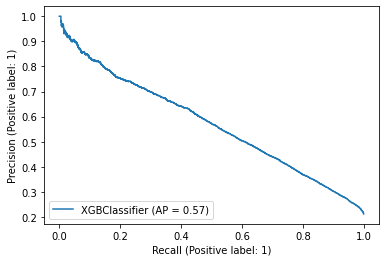

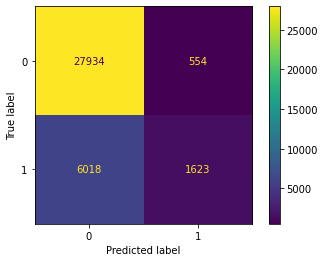

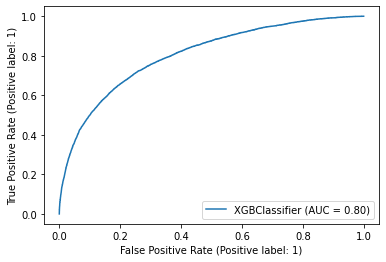

In [ ]:
## XGB

from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier


## encoding labels
# print(y_test[:10])

y_train.replace({False: 0, True: 1}, inplace=True)
y_test.replace({False: 0, True: 1}, inplace=True)

# print(y_test[:10])

ensemble_model = XGBClassifier(use_label_encoder=False)#, max_depth =7)
# ensemble_model = AdaBoostClassifier()#(max_depth = 7)
# ensemble_model = BaggingClassifier()
# ensemble_model = HistGradientBoostingClassifier()


## TO TRY
# ensemble_model = ExtraTreesClassifier()
# ensemble_model = GradientBoostingClassifier()



# ensemble_modelrf = XGBRFClassifier()

ensemble_model.fit(X_train,y_train)
# ensemble_model.fit(X_train,y_train, eval_metric='aucpr')


# ensemble_modelrf.fit(X_train,y_train)

pred_y = ensemble_model.predict(X_test)
# pred_y = ensemble_modelrf.predict(X_test)

cm = confusion_matrix(y_test,pred_y)
tn,fp,fn,tp = cm.ravel()
# print(tn,fp,fn,tp)
# print("Before pruning:\n")
print("After pruning:\n")
print("Accuracy: ",(tp+tn)/(tp+tn+fp+fn))
print("Precision: ", tp/(tp+fp))
print("Recall: ", tp/(tp+fn))
print("Sensitivity: ", tp/(tp+fn))
print("Specificity: ",tn/(tn+fp))
pr = tp/(tp+fp)
rc = tp/(tp+fn)
print("F1 score: ", (2*pr*rc)/(pr+rc))


# ##ensemble_model
PrecisionRecallDisplay.from_estimator(ensemble_model,X_test,y_test,pos_label=1)
ConfusionMatrixDisplay.from_estimator(ensemble_model,X_test,y_test)
RocCurveDisplay.from_estimator(ensemble_model,X_test,y_test,pos_label=1)


In [ ]:
## Pre-pruning

hyper_p = {
"min_samples_split":(6,8,10),
"min_samples_leaf":(1,2,3,4,5,6)
}

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

DT_all = GridSearchCV(DecisionTreeClassifier(max_depth=6), param_grid=hyper_p,  cv = 3)

DT_all.fit(X_train,y_train)

print(DT_all.best_estimator_)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=2, min_samples_split=8)


In [ ]:
# print(dataset.shape)
dt1 = DecisionTreeClassifier()
dt1.fit(X_train,y_train)

# PrecisionRecallDisplay.from_estimator(dt1,X_test,y_test,pos_label=1)
# ConfusionMatrixDisplay.from_estimator(dt1,X_test,y_test)
# RocCurveDisplay.from_estimator(dt1,X_test,y_test,pos_label=1)

